# HDBSCAN & DBSCAN Analysis

* **DBSCAN** is a density based clustering algorithm. Instead of guessing how many clusters are needed, we define the hyperparameters ∈ and 𝑛.
The advantage of DBSCAN is that it can build clusters that have an arbitrary shape, while k-means and other centroid-based algorithms create clusters that have a shape of a hypersphere. The drawback is that it has 2 hyperparameters and choosing good values for them (especially ∈) can be challenging. Also, with a fixed ∈, the clustering algorithm cannot effectively deal with clusters of varying density.

* **HDBSCAN** has the same advantages as DBSCAN but only has 1 hyperparameter (𝑛). It can build clusters of varying density. 
  * 𝑛: the minimum number of examples to put in a cluster (simple to choose by intuition)

### References

[1] Andriy Burkov, *The Hundred-Page Machine Learning Book*, 2019.

[2] Aurélien Géron, *Hands-On Machine Learning with Scikit-Learn and PyTorch*, 1st ed., O'Reilly Media, 2025.

[3] Scikit-learn Developers, "DBSCAN", Scikit-learn documentation:
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

[4] Scikit-learn Developers, "HDBSCAN", Scikit-learn documentation:
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html

*Date: Jun 8, 2026 - By: Tomás Silva*

## 1. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import hdbscan
import umap

## 2. Load 692799 I(q) sample data

In [2]:
file_path = 'Data/692799 IQ_fitting.csv'
df_day4 = pd.read_csv(file_path)
display(df_day4.head())

features = ['D_period', 'wp', 'area under third order curve', 'peak_width']

base_means = {}
base_stds = {}

print("--- Real Data Baselines (Day 4) ---\n")
for feature in features:
    mean_val = df_day4[feature].mean()
    std_val = df_day4[feature].std()
    
    base_means[feature] = mean_val
    base_stds[feature] = std_val
    
    print(f"Feature: {feature}")
    print(f"  Mean: {mean_val:.6f}")
    print(f"  Std Dev: {std_val:.6f}\n")

,x,y,total SAXS intensity,total_SAXS_norm_0_1,area under third order curve,collagen_third_norm_0_1,percentage_above_baseline,max_recorded_intensity,firstmoment,secondmoment,...,wMu,firstmoment_lu,secondmoment_lu,thirdmoment_lu,skewness_lu,D_period,peak_width,wp,peak_amplitude,fibril_radius
0,0,0,0.018897,0.004010,0.000000,1.000000e-09,34.733524,0.007163,0.281151,0.0791,...,0.187551,0.306105,0.0938,0.028730,2.599635,62.623109,0.001,0.056453,1,47.237054
1,1,0,0.019003,0.004349,0.000017,2.971487e-02,63.363078,0.005062,0.290088,0.0842,...,0.021837,0.292087,0.0853,0.024920,-0.144198,64.553274,0.001,0.006376,1,418.213630
2,2,0,0.018621,0.003124,0.000021,3.670660e-02,61.695855,0.004631,0.297568,0.0886,...,0.010000,0.282080,0.0796,0.022446,-0.662833,66.842397,0.001,0.002820,1,945.626478
3,3,0,0.019072,0.004572,0.000000,1.000000e-09,28.452648,0.006882,0.300850,0.0906,...,0.010000,0.282080,0.0796,0.022446,-0.662833,66.842397,0.001,0.002820,1,945.626478
4,4,0,0.019987,0.007506,0.000094,1.643057e-01,93.781777,0.005867,0.294687,0.0869,...,0.015918,0.297081,0.0883,0.026220,-0.503788,63.466518,0.001,0.004728,1,564.045008


--- Real Data Baselines (Day 4) ---

Feature: D_period
  Mean: 65.824251
  Std Dev: 1.510265

Feature: wp
  Mean: 0.023034
  Std Dev: 0.021533

Feature: area under third order curve
  Mean: 0.000118
  Std Dev: 0.000161

Feature: peak_width
  Mean: 0.003298
  Std Dev: 0.003104



## 3. Generate Pseudo-Data with 5 sections

In [3]:
# 1. Initialise empty grids (100 rows, 200 cols)
rows, cols = 100, 200
pseudo_dp = np.zeros((rows, cols))
pseudo_wp = np.zeros((rows, cols))
pseudo_area = np.zeros((rows, cols))
pseudo_pw = np.zeros((rows, cols))

noise_multiplier = 0.5 # originally tested with 0.25 (1 was too high)

# 2. Populate the grid with 5 WAVY zones
for r in range(rows):
    # Create sine wave borders
    bound_1 = int(40 + np.sin(r / 3.0) * 4)
    bound_2 = int(80 + np.sin(r / 12.0) * 9)
    bound_3 = int(120 + np.sin(r / 5.5) * 5)
    bound_4 = int(160 + np.sin(r / 12) * 12)

    for c in range(cols):
        # Determine the zone based on wavy boundaries
        if c < bound_1: shift = 0.0       # Zone 0: Healthy
        elif c < bound_2: shift = 1.0     # Zone 1: Mild
        elif c < bound_3: shift = 2.0     # Zone 2: Moderate
        elif c < bound_4: shift = 3.0     # Zone 3: Severe
        else: shift = 4.0                 # Zone 4: Core Wound

        # Apply values with random noise (noise_multipler * std)
        pseudo_dp[r, c] = np.random.normal(
            base_means['D_period'] + (shift * base_stds['D_period']), 
            base_stds['D_period'] * noise_multiplier)
        
        pseudo_wp[r, c] = np.random.normal(
            base_means['wp'] + (shift * base_stds['wp']), 
            base_stds['wp'] * noise_multiplier)
        
        pseudo_area[r, c] = np.random.normal(
            base_means['area under third order curve'] + (shift * base_stds['area under third order curve']), 
            base_stds['area under third order curve'] * noise_multiplier)
        
        pseudo_pw[r, c] = np.random.normal(
            base_means['peak_width'] + (shift * base_stds['peak_width']), 
            base_stds['peak_width'] * noise_multiplier)

### 3.1 Verify the 5-Cluster Plot

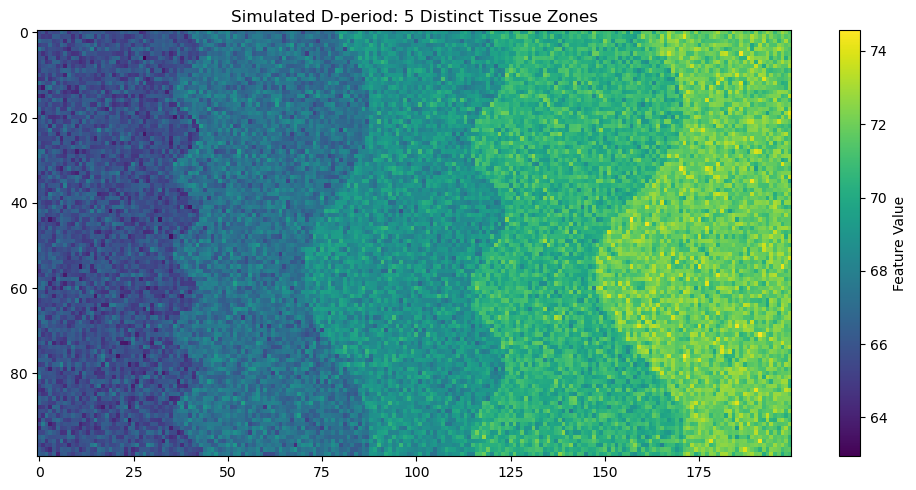

In [4]:
plt.figure(figsize=(10, 5))
plt.imshow(pseudo_dp, cmap='viridis', aspect='auto')
plt.title('Simulated D-period: 5 Distinct Tissue Zones')
plt.colorbar(label='Feature Value')
plt.tight_layout()
plt.show()

### 3.2 Visualise the synthetic data (3D plot)

Features: 
 - D-period
 - Area Under the 3rd Order Curve
 - Degree of Orientation (wp)

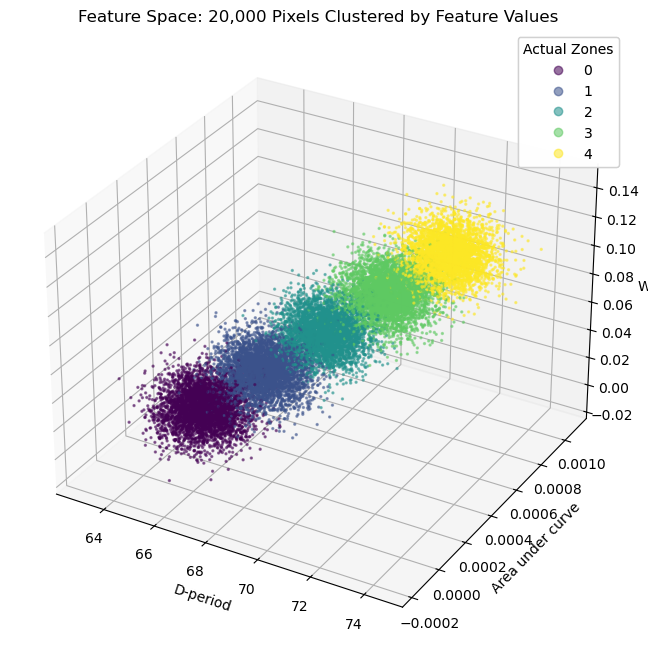

In [5]:
import matplotlib.pyplot as plt

# 1. Recreate the exact ground truth labels so we can color-code the clouds
true_labels = np.zeros((rows, cols))
for r in range(rows):
    bound_1 = int(40 + np.sin(r / 3.0) * 4)
    bound_2 = int(80 + np.sin(r / 12.0) * 9)
    bound_3 = int(120 + np.sin(r / 5.5) * 5)
    bound_4 = int(160 + np.sin(r / 12.0) * 12)
    for c in range(cols):
        if c < bound_1: true_labels[r, c] = 0
        elif c < bound_2: true_labels[r, c] = 1
        elif c < bound_3: true_labels[r, c] = 2
        elif c < bound_4: true_labels[r, c] = 3
        else: true_labels[r, c] = 4

# 2. Flatten the matrices to 1D arrays (20,000 individual dots)
flat_dp = pseudo_dp.flatten()
flat_area = pseudo_area.flatten()
flat_wp = pseudo_wp.flatten()
flat_labels = true_labels.flatten()

# 3. Create the 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the 20,000 points. 
# s=2 makes the dots small so we can see the density. alpha=0.5 makes them slightly transparent.
scatter = ax.scatter(flat_dp, flat_area, flat_wp, c=flat_labels, cmap='viridis', s=2, alpha=0.5)

ax.set_xlabel('D-period')
ax.set_ylabel('Area under curve')
ax.set_zlabel('WP')
ax.set_title('Feature Space: 20,000 Pixels Clustered by Feature Values')

# Add a legend
legend = ax.legend(*scatter.legend_elements(), title="Actual Zones")
ax.add_artist(legend)

plt.show()

## 4. Kmeans model

Evaluate how standard K-means handles our simulated tissue data when forced to find a specific number of boundaries.
 * **Data Preparation**: Flatten the 2D grids into a 1D list and scale all four features so they have equal weight in the model.
 * **Experiment**: Run the algorithm three seperate times on the eaxct same data, strictly forcing it to find 3, 4 and 5 clusters.
 * **Goal**: Plot these three predictions side-by-side against the ground truth (with 5 zones) to visually demonstrate how standard K-means behaves-and strugles-when defining complex biological boundaries. 

K-means finished testing 3, 4, and 5 clusters!


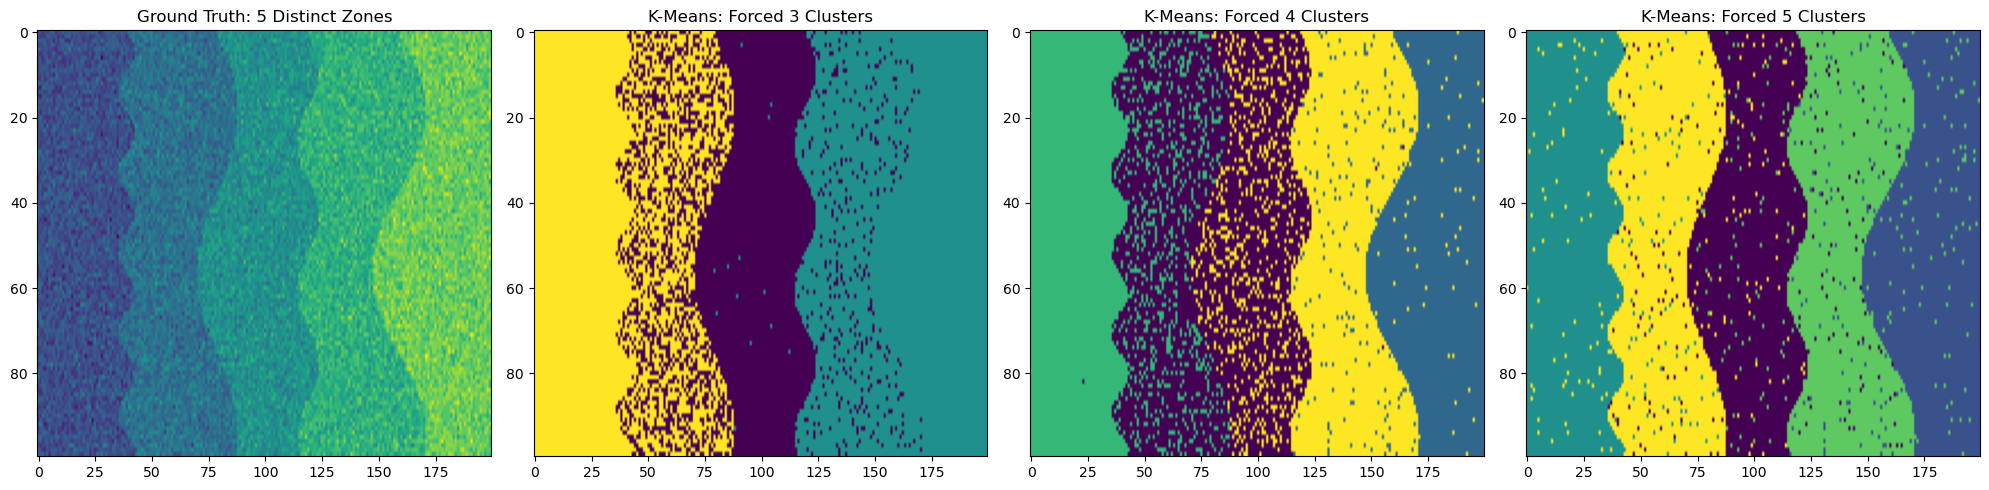

In [13]:
# Flatten and stack the features
flat_dp = pseudo_dp.reshape(-1, 1)
flat_wp = pseudo_wp.reshape(-1, 1)
flat_area = pseudo_area.reshape(-1, 1)
flat_pw = pseudo_pw.reshape(-1, 1)

X_pseudo = np.hstack((flat_dp, flat_area, flat_wp, flat_pw))

# Scale the data (each feature has its own order)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pseudo)

# Run the model in a loop for 3, 4 and 5 clusters
cluster_tests = [3, 4, 5]
kmeans_results = {} # Stores results in a dictionary

for k in cluster_tests:
    # Build and run the model in one line for each 'k'
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit_predict(X_scaled)
    
    # Reshape the 1D labels back into our 100x200 image format and save it
    kmeans_results[k] = kmeans.reshape(100, 200)

print("K-means finished testing 3, 4, and 5 clusters!")

# Plot the results

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(pseudo_dp, cmap='viridis', aspect='auto')
axes[0].set_title("Ground Truth: 5 Distinct Zones")

axes[1].imshow(kmeans_results[3], cmap='viridis', aspect='auto')
axes[1].set_title("K-Means: Forced 3 Clusters")

axes[2].imshow(kmeans_results[4], cmap='viridis', aspect='auto')
axes[2].set_title("K-Means: Forced 4 Clusters")

axes[3].imshow(kmeans_results[5], cmap='viridis', aspect='auto')
axes[3].set_title("K-Means: Forced 5 Clusters")

plt.tight_layout()
plt.show()

## 5. HDBSCAN

 - Run HDBSCAN for 3 different $min_cluster_size$ values: `50, 200 and 1500`.
 - min_samples is set to default, so $min_samples$ = $min_cluster_size$.

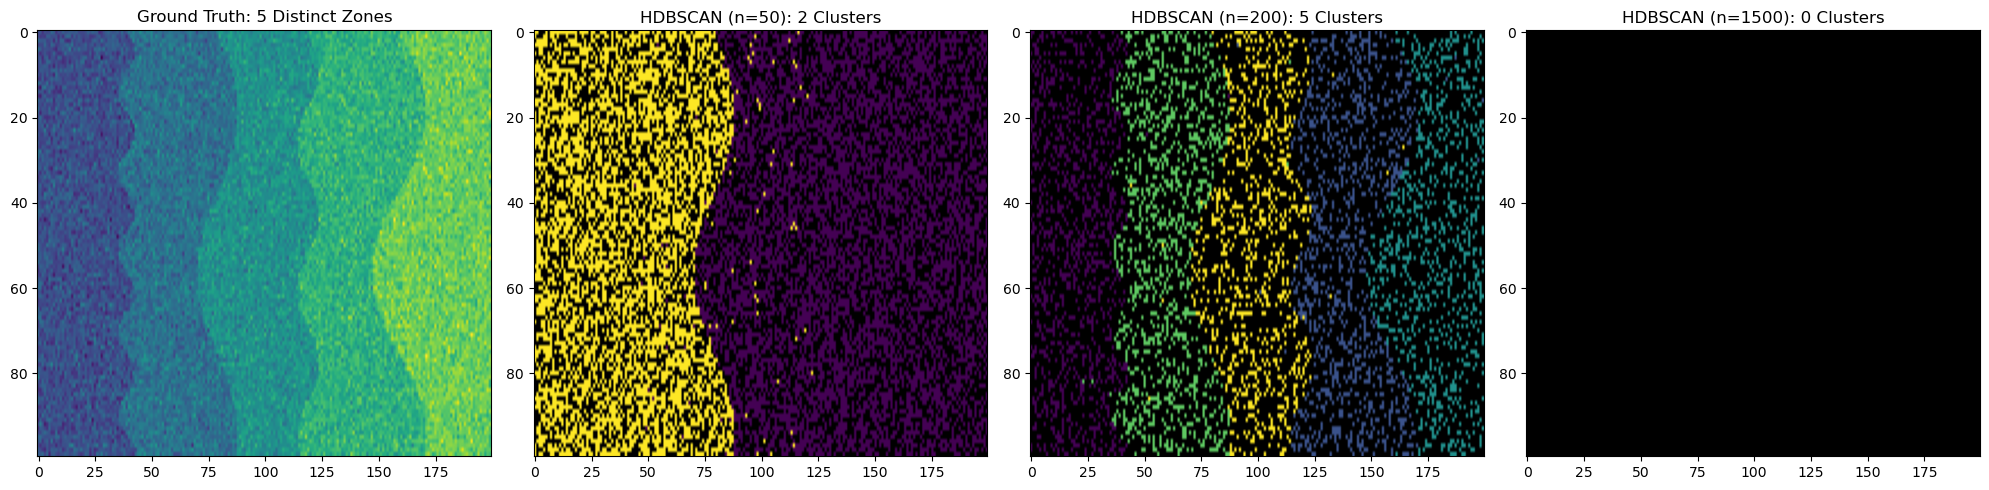

In [14]:
# 1. Run HDBSCAN for 3 different min_cluster_size values (default min_samples)

# Configuration A: n=50 (Under-segmentation)
hdb_50 = hdbscan.HDBSCAN(min_cluster_size=50)
labels_50 = hdb_50.fit_predict(X_scaled)
seg_50 = labels_50.reshape(100, 200)
num_50 = len(set(labels_50)) - (1 if -1 in labels_50 else 0)

# Configuration B: n=200 (Optimal Baseline)
hdb_200 = hdbscan.HDBSCAN(min_cluster_size=200)
labels_200 = hdb_200.fit_predict(X_scaled)
seg_200 = labels_200.reshape(100, 200)
num_200 = len(set(labels_200)) - (1 if -1 in labels_200 else 0)

# Configuration C: n=1500 (Over-segmentation / Failure)
hdb_1500 = hdbscan.HDBSCAN(min_cluster_size=1500)
labels_1500 = hdb_1500.fit_predict(X_scaled)
seg_1500 = labels_1500.reshape(100, 200)
num_1500 = len(set(labels_1500)) - (1 if -1 in labels_1500 else 0)

# 2. Plotting 1x4 comparison
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(pseudo_dp, cmap='viridis', aspect='auto')
axes[0].set_title("Ground Truth: 5 Distinct Zones")

# Custom colormap to make noise (-1) black
cmap_hdb = plt.cm.viridis.copy()
cmap_hdb.set_under('black')

# Add vmax=max(1, seg.max()) to prevent Matplotlib crashing on all-noise arrays
axes[1].imshow(seg_50, cmap=cmap_hdb, aspect='auto', vmin=0, vmax=max(1, seg_50.max()))
axes[1].set_title(f"HDBSCAN (n=50): {num_50} Clusters")

axes[2].imshow(seg_200, cmap=cmap_hdb, aspect='auto', vmin=0, vmax=max(1, seg_200.max()))
axes[2].set_title(f"HDBSCAN (n=200): {num_200} Clusters")

axes[3].imshow(seg_1500, cmap=cmap_hdb, aspect='auto', vmin=0, vmax=max(1, seg_1500.max()))
axes[3].set_title(f"HDBSCAN (n=1500): {num_1500} Clusters")

plt.tight_layout()
plt.show()

### 3D Feature Space

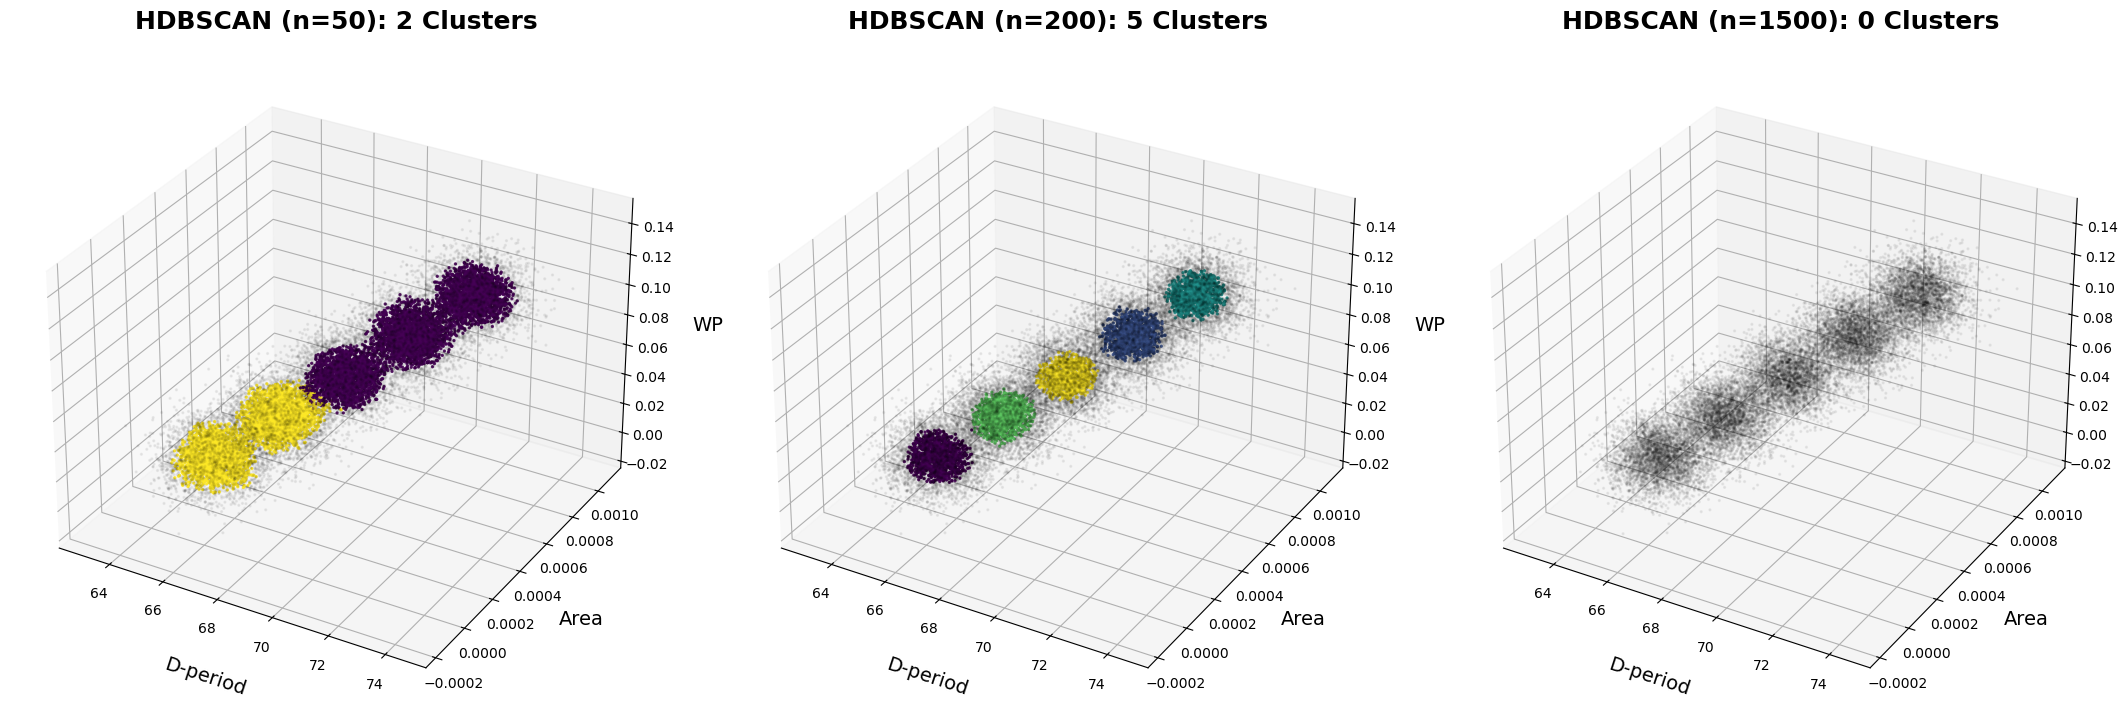

In [27]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(24, 10))

# --- Plot 1: n=50 ---
ax1 = fig.add_subplot(131, projection='3d')
noise_50 = (labels_50 == -1)
cluster_50 = (labels_50 != -1)

ax1.scatter(flat_dp[noise_50], flat_area[noise_50], flat_wp[noise_50], 
           c='black', s=2, alpha=0.05)
ax1.scatter(flat_dp[cluster_50], flat_area[cluster_50], flat_wp[cluster_50], 
           c=labels_50[cluster_50], cmap='viridis', s=2, alpha=0.8)

ax1.set_xlabel('D-period', fontsize=14, labelpad=15)
ax1.set_ylabel('Area', fontsize=14, labelpad=15)
ax1.set_zlabel('WP', fontsize=14, labelpad=15)

# --- Plot 2: n=200 ---
ax2 = fig.add_subplot(132, projection='3d')
noise_200 = (labels_200 == -1)
cluster_200 = (labels_200 != -1)

ax2.scatter(flat_dp[noise_200], flat_area[noise_200], flat_wp[noise_200], 
           c='black', s=2, alpha=0.05)
ax2.scatter(flat_dp[cluster_200], flat_area[cluster_200], flat_wp[cluster_200], 
           c=labels_200[cluster_200], cmap='viridis', s=2, alpha=0.8)

ax2.set_xlabel('D-period', fontsize=14, labelpad=15)
ax2.set_ylabel('Area', fontsize=14, labelpad=15)
ax2.set_zlabel('WP', fontsize=14, labelpad=15)

# --- Plot 3: n=1500 ---
ax3 = fig.add_subplot(133, projection='3d')
noise_1500 = (labels_1500 == -1)
cluster_1500 = (labels_1500 != -1)

ax3.scatter(flat_dp[noise_1500], flat_area[noise_1500], flat_wp[noise_1500], 
           c='black', s=2, alpha=0.05)
if cluster_1500.any():
    ax3.scatter(flat_dp[cluster_1500], flat_area[cluster_1500], flat_wp[cluster_1500], 
               c=labels_1500[cluster_1500], cmap='viridis', s=2, alpha=0.8)

ax3.set_xlabel('D-period', fontsize=14, labelpad=15)
ax3.set_ylabel('Area', fontsize=14, labelpad=15)
ax3.set_zlabel('WP', fontsize=14, labelpad=15)


title_kwargs = {'fontsize': 18, 'fontweight': 'bold', 'pad': 20}
ax1.set_title('HDBSCAN (n=50): 2 Clusters', **title_kwargs)
ax2.set_title('HDBSCAN (n=200): 5 Clusters', **title_kwargs)
ax3.set_title('HDBSCAN (n=1500): 0 Clusters', **title_kwargs)

# Force padding between the 3D plots so they don't overlap
plt.tight_layout(pad=4.0, w_pad=5.0, rect=[0, 0, 0.92, 1])
plt.show()

Noise Check

In [8]:
# Calculate the exact number of noise pixels (labeled as -1) for the n=200 model
noise_count = np.sum(labels_200 == -1)
total_pixels = len(labels_200) # 20,000 total pixels (100x200)
noise_percentage = (noise_count / total_pixels) * 100

print(f"--- Noise Statistics for HDBSCAN (n=200) ---")
print(f"Total pixels: {total_pixels}")
print(f"Noise pixels (black): {noise_count}")
print(f"Percentage of image classified as noise: {noise_percentage:.2f}%")

--- Noise Statistics for HDBSCAN (n=200) ---
Total pixels: 20000
Noise pixels (black): 14839
Percentage of image classified as noise: 74.19%


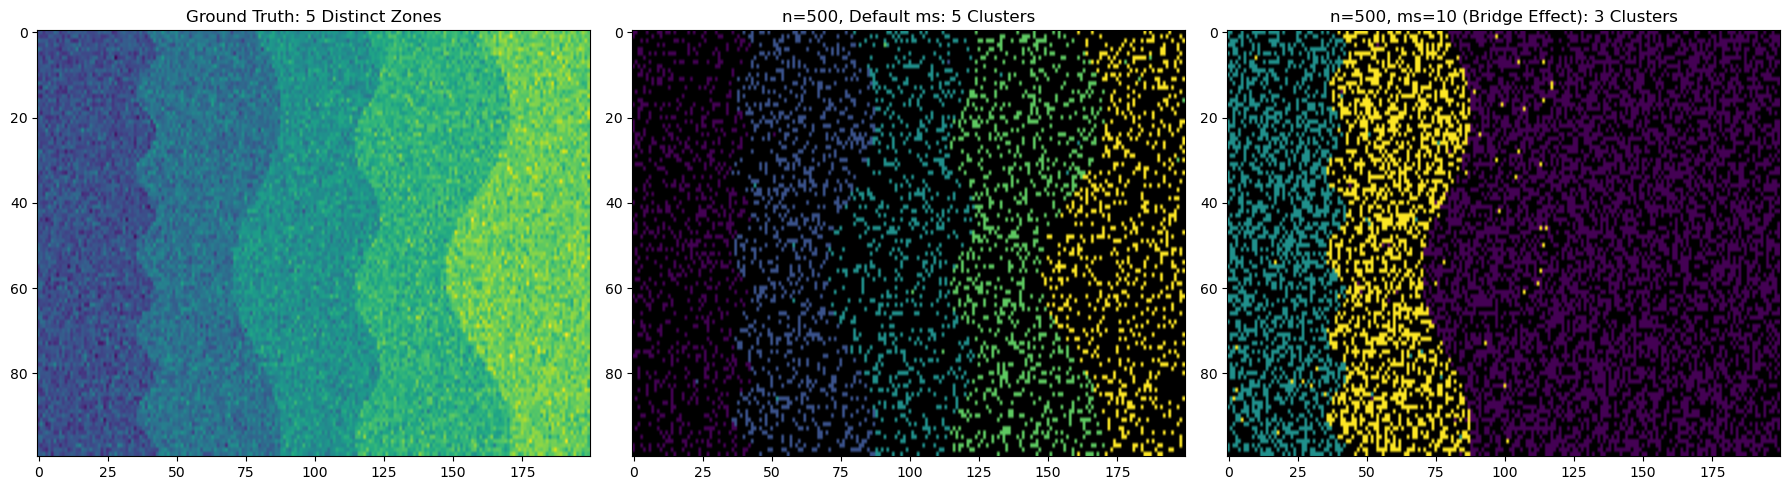

In [9]:
# 1. Decoupling min_cluster_size and min_samples to test boundary strictness

# Baseline: n=500 with default min_samples (which becomes 500)
hdb_500_def = hdbscan.HDBSCAN(min_cluster_size=500)
labels_500_def = hdb_500_def.fit_predict(X_scaled)
seg_500_def = labels_500_def.reshape(100, 200)
num_500_def = len(set(labels_500_def)) - (1 if -1 in labels_500_def else 0)

# Test: n=500 but highly permissive min_samples (ms=10)
hdb_500_ms10 = hdbscan.HDBSCAN(min_cluster_size=500, min_samples=10)
labels_500_ms10 = hdb_500_ms10.fit_predict(X_scaled)
seg_500_ms10 = labels_500_ms10.reshape(100, 200)
num_500_ms10 = len(set(labels_500_ms10)) - (1 if -1 in labels_500_ms10 else 0)

# 2. Plotting 1x3 comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(pseudo_dp, cmap='viridis', aspect='auto')
axes[0].set_title("Ground Truth: 5 Distinct Zones")

# Custom colormap to make noise (-1) black (redefined here just in case)
cmap_hdb = plt.cm.viridis.copy()
cmap_hdb.set_under('black')

# Add vmax safeguard here too
axes[1].imshow(seg_500_def, cmap=cmap_hdb, aspect='auto', vmin=0, vmax=max(1, seg_500_def.max()))
axes[1].set_title(f"n=500, Default ms: {num_500_def} Clusters")

axes[2].imshow(seg_500_ms10, cmap=cmap_hdb, aspect='auto', vmin=0, vmax=max(1, seg_500_ms10.max()))
axes[2].set_title(f"n=500, ms=10 (Bridge Effect): {num_500_ms10} Clusters")

plt.tight_layout()
plt.show()